In [1]:
from crafter_analysis import common
import collections
import json
import pathlib

import numpy as np

In [ ]:
def read_stats(indir, outdir, task, method, budget=int(1e6), verbose=False):
  indir = pathlib.Path(indir)
  outdir = pathlib.Path(outdir)
  runs = []
  print(f'Loading {indir.name}...')
  filenames = sorted(list(indir.glob('**/stats.jsonl')))
  for index, filename in enumerate(filenames):
    if not filename.is_file():
      continue
    rewards, lengths, achievements = load_stats(filename, budget)
    if sum(lengths) < budget - 1e4:
      message = f'Skipping incomplete run ({sum(lengths)} < {budget} steps): '
      message += f'{filename.relative_to(indir.parent)}'
      print(f'==> {message}')
      continue
    runs.append(dict(
        task=task,
        method=method,
        seed=str(index),
        xs=np.cumsum(lengths).tolist(),
        reward=rewards,
        length=lengths,
        **achievements,
    ))
  if not runs:
    print('No completed runs.\n')
    return
  print_summary(runs, budget, verbose)
  outdir.mkdir(exist_ok=True, parents=True)
  filename = (outdir / f'{task}-{method}.json')
  filename.write_text(json.dumps(runs))
  print('Wrote', filename)
  print('')


def load_stats(filename, budget):
  steps = 0
  rewards = []
  lengths = []
  achievements = collections.defaultdict(list)
  for line in filename.read_text().split('\n'):
    if not line.strip():
      continue
    episode = json.loads(line)
    steps += episode['length']
    if steps > budget:
      break
    lengths.append(episode['length'])
    for key, value in episode.items():
      if key.startswith('achievement_'):
        achievements[key].append(value)
    unlocks = int(np.sum([(v[-1] >= 1) for v in achievements.values()]))
    health = -0.9
    rewards.append(unlocks + health)
  return rewards, lengths, achievements


def print_summary(runs, budget, verbose):
  episodes = np.array([len(x['length']) for x in runs])
  rewards = np.array([np.mean(x['reward']) for x in runs])
  lengths = np.array([np.mean(x['length']) for x in runs])
  percents, methods, seeds, tasks = common.compute_success_rates(
      runs, budget, sortby=0)
  scores = np.squeeze(common.compute_scores(percents))
  print(f'Score:        {np.mean(scores):10.2f} ± {np.std(scores):.2f}')
  print(f'Reward:       {np.mean(rewards):10.2f} ± {np.std(rewards):.2f}')
  print(f'Length:       {np.mean(lengths):10.2f} ± {np.std(lengths):.2f}')
  print(f'Episodes:     {np.mean(episodes):10.2f} ± {np.std(episodes):.2f}')
  if verbose:
    for task, percent in sorted(tasks, np.squeeze(percents).T):
      name = task[len('achievement_'):].replace('_', ' ').title()
      print(f'{name:<20}  {np.mean(percent):6.2f}%')


In [11]:
# file_path = "logs/crafter/CTEC/CTEC_env_crafter_discount_0.3_normalize_repr_1_ctec_energy_fn_l2_ctec_loss_fn_infonce"
# output_path = "logs/crafter/CTEC/CTEC_env_crafter_discount_0.3_normalize_repr_1_ctec_energy_fn_l2_ctec_loss_fn_infonce"
# method = "ctec"
file_path = "logs/crafter/TDD/TDD_env_crafter/"
output_path = "logs/crafter/TDD/TDD_env_crafter/"
method = "ctec"
task="crafter"
budget=2433024
read_stats(file_path, output_path, task, method, budget=budget)

Loading TDD_env_crafter...
[PosixPath('logs/crafter/TDD/TDD_env_crafter/1/stats/stats.jsonl'), PosixPath('logs/crafter/TDD/TDD_env_crafter/2/stats/stats.jsonl'), PosixPath('logs/crafter/TDD/TDD_env_crafter/3/stats/stats.jsonl'), PosixPath('logs/crafter/TDD/TDD_env_crafter/4/stats/stats.jsonl')]
Score:              0.33 ± 0.05
Reward:            -0.78 ± 0.03
Length:           184.72 ± 1.68
Episodes:       13172.25 ± 120.90
Wrote logs/crafter/TDD/TDD_env_crafter/crafter-ctec.json



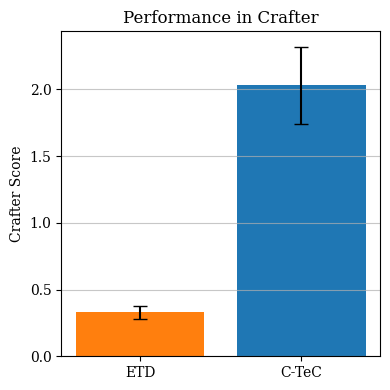

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Example data
labels = ["ETD", "C-TeC"]
means = [0.33, 2.03]
stds = [0.05, 0.29]

x = np.arange(len(labels))  # label locations
width = 0.8  # bar width
palette = sns.color_palette("tab10", n_colors=len(labels))[::-1]
algo_colors = dict(zip(labels, palette))
# Create bar plot
# plt.figure(figsize=(5, 3))
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(x, means, width, yerr=stds, capsize=5, color=palette,)

# Add labels and title
ax.set_ylabel('Crafter Score')
ax.set_title('Performance in Crafter')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', alpha=0.7)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.tight_layout()
plt.savefig("Crafter_etd_ctec.png", dpi=200)
plt.savefig("Crafter_etd_ctec.pdf", dpi=200)
plt.show()
